# Algeria Export Opportunity Analysis
**ENSIA — Machine Learning Project, Spring 2025-2026**

This notebook covers the full analytical pipeline:

1. Data loading and overview
2. Data preprocessing and missing value handling
3. Feature engineering
4. Feature reduction (correlation analysis + PCA)
5. Exploratory data analysis (EDA)
6. modeling

**Input:** `world_trade_data_enriched.csv` — one row per `(year, importer, product)` combining UN Comtrade flows (2012–2024), World Bank indicators, CEPII gravity features, and HS4 sector metadata.

Rows where `exporter = 'world'` represent aggregate import demand. Rows where `exporter = '12'` represent Algeria's actual bilateral exports.

## 0. Imports and configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

INPUT_FILE  = '../data/world_trade_data_enriched.csv'
OUTPUT_FILE = '../data/world_trade_data_features.csv'
PCA_FILE    = '../data/world_trade_data_pca.csv'
ALGERIA_STR = '12'

---
## 1. Data loading and overview

In [4]:
df = pd.read_csv(INPUT_FILE, dtype={'product': str, 'exporter': str})
df['product'] = df['product'].str.zfill(4)

world = df[df['exporter'] == 'world'].copy()
alg   = df[df['exporter'] == ALGERIA_STR].copy()

print(f'Total rows      : {len(df):,}')
print(f'World rows      : {len(world):,}')
print(f'Algeria rows    : {len(alg):,}')
print(f'Years           : {sorted(df["year"].unique())}')
print(f'Importers       : {df["importer"].nunique()}')
print(f'Products        : {df["product"].nunique()}')

Total rows      : 1,546,470
World rows      : 1,501,178
Algeria rows    : 45,292
Years           : [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Importers       : 97
Products        : 1224


In [5]:
world.head(5)

,year,importer,exporter,product,total_value,total_qty,gdp_usd,gdp_per_capita,gdp_growth_rate,population,trade_openness,inflation_rate,shares_border,common_language_off,common_language_eth,colonial_link,common_colonizer,distance_km,distance_capitals,distance_weighted,continent,official_language,main_spoken_language,is_landlocked,hs2_chapter,hs_section,sector
0,2012,24,world,0101,621.7000,58.6300,143572907527.9760,5702.4531,8.5031,25177394.0000,81.9395,10.2779,0.0000,0.0000,0.0000,0.0000,0.0000,5194.2440,5194.2440,5223.2270,Africa,Portuguese,Portuguese,0.0000,1,0,Agriculture & Food
1,2012,24,world,0102,12499.0170,2776.6980,143572907527.9760,5702.4531,8.5031,25177394.0000,81.9395,10.2779,0.0000,0.0000,0.0000,0.0000,0.0000,5194.2440,5194.2440,5223.2270,Africa,Portuguese,Portuguese,0.0000,1,0,Agriculture & Food
2,2012,24,world,0105,578.4740,33.0590,143572907527.9760,5702.4531,8.5031,25177394.0000,81.9395,10.2779,0.0000,0.0000,0.0000,0.0000,0.0000,5194.2440,5194.2440,5223.2270,Africa,Portuguese,Portuguese,0.0000,1,0,Agriculture & Food
3,2012,24,world,0106,38.9280,1.5370,143572907527.9760,5702.4531,8.5031,25177394.0000,81.9395,10.2779,0.0000,0.0000,0.0000,0.0000,0.0000,5194.2440,5194.2440,5223.2270,Africa,Portuguese,Portuguese,0.0000,1,0,Agriculture & Food
4,2012,24,world,0201,2109.1790,268.8610,143572907527.9760,5702.4531,8.5031,25177394.0000,81.9395,10.2779,0.0000,0.0000,0.0000,0.0000,0.0000,5194.2440,5194.2440,5223.2270,Africa,Portuguese,Portuguese,0.0000,2,0,Agriculture & Food


In [6]:
world.describe()

,year,importer,total_value,total_qty,gdp_usd,gdp_per_capita,gdp_growth_rate,population,trade_openness,inflation_rate,shares_border,common_language_off,common_language_eth,colonial_link,common_colonizer,distance_km,distance_capitals,distance_weighted,is_landlocked,hs2_chapter,hs_section
count,1501178.0000,1501178.0000,1501178.0000,1501178.0000,1469744.0000,1469744.0000,1469744.0000,1470892.0000,1416289.0000,1449549.0000,1485592.0000,1485592.0000,1485592.0000,1485592.0000,1485592.0000,1485592.0000,1485592.0000,1485592.0000,1485592.0000,1501178.0000,1501178.0000
mean,2018.0012,435.8616,151637.7780,107162.4009,914196755264.3357,22824.1489,2.6682,70698162.1390,95.3813,6.0825,0.0300,0.2062,0.1956,0.0107,0.0511,5454.5815,5438.8950,5504.9195,0.1241,52.9843,4.8382
std,3.7380,256.4019,1720578.8250,3953846.3841,2731135848219.9487,24691.9173,5.0413,203835703.6298,66.8852,15.7560,0.1705,0.4046,0.3967,0.1029,0.2203,3854.1131,3840.5095,3834.0141,0.3297,27.5153,2.8199
min,2012.0000,24.0000,0.0010,0.0000,9609532089.1603,859.6805,-29.9986,420028.0000,22.4862,-12.2970,0.0000,0.0000,0.0000,0.0000,0.0000,642.7219,642.7219,650.6020,0.0000,1.0000,0.0000
25%,2015.0000,208.0000,791.3368,111.4770,65005997963.4822,4297.2678,1.1793,5984119.0000,52.3471,1.3722,0.0000,0.0000,0.0000,0.0000,0.0000,1971.1890,1971.1890,2080.4850,0.0000,28.0000,2.0000
50%,2018.0000,414.0000,6721.1835,1217.6325,217308516483.5160,12949.7175,2.8681,17049547.0000,75.9981,2.8992,0.0000,0.0000,0.0000,0.0000,0.0000,4358.6750,4358.6750,4345.6440,0.0000,54.0000,5.0000
75%,2021.0000,643.0000,42234.5990,10036.8390,542638913427.9210,35326.7683,4.9231,51585058.0000,120.8419,6.0770,0.0000,0.0000,0.0000,0.0000,0.0000,9103.7260,9103.7260,9119.9030,0.0000,81.0000,8.0000
max,2024.0000,894.0000,333316419.7740,1177057563.5530,28750956130731.1992,137781.6817,86.8267,1450935791.0000,442.6200,254.9485,1.0000,1.0000,1.0000,1.0000,1.0000,18953.2300,18953.2300,19107.9900,1.0000,97.0000,9.0000


---
## 2. Preprocessing and missing value handling

We address three types of missingness:
- **Economic indicators** (World Bank): small year gaps filled by forward/backward fill within each country (valid because GDP and population change slowly.)
- **Gravity features** (CEPII): a small fraction of importers unmatched in the bilateral file; filled with column median.
- **Categorical geo columns**: filled with `'Unknown'`.

### 2.1 Missing value audit

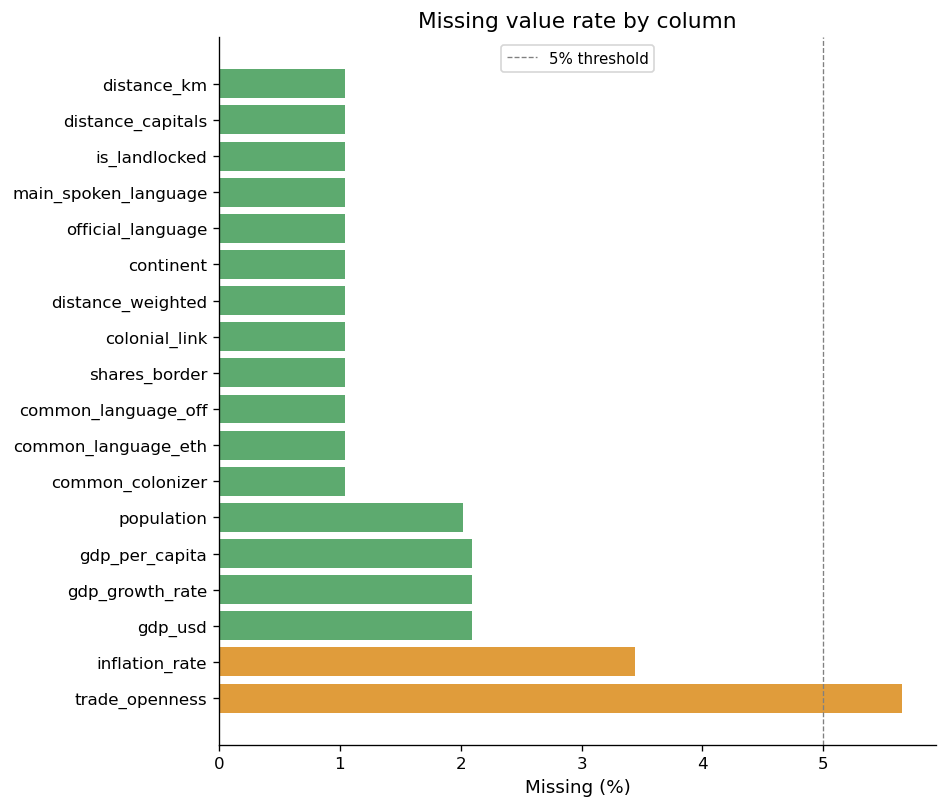

trade_openness         5.6500
inflation_rate         3.4400
gdp_usd                2.0900
gdp_growth_rate        2.0900
gdp_per_capita         2.0900
population             2.0200
common_colonizer       1.0400
common_language_eth    1.0400
common_language_off    1.0400
shares_border          1.0400
colonial_link          1.0400
distance_weighted      1.0400
continent              1.0400
official_language      1.0400
main_spoken_language   1.0400
is_landlocked          1.0400
distance_capitals      1.0400
distance_km            1.0400
Name: missing_%, dtype: float64

In [7]:
missing = world.isnull().mean().mul(100).round(2).sort_values(ascending=False)
missing = missing[missing > 0].rename('missing_%')

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.38)))
    colors = ['#d64e4e' if v > 10 else '#e09c3b' if v > 3 else '#5daa6f' for v in missing.values]
    ax.barh(missing.index, missing.values, color=colors)
    ax.axvline(5, color='gray', linewidth=0.8, linestyle='--', label='5% threshold')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing value rate by column')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

missing

### 2.2 Fill economic indicators (forward/backward fill per country)

In [8]:
eco_cols = ['gdp_usd','gdp_per_capita','gdp_growth_rate','population','trade_openness','inflation_rate']
world = world.sort_values(['importer','year'])
for col in eco_cols:
    world[col] = world.groupby('importer')[col].transform(lambda x: x.ffill().bfill())

gravity_num = ['distance_km','distance_capitals','distance_weighted',
               'shares_border','common_language_off','common_language_eth',
               'colonial_link','common_colonizer','is_landlocked']
for col in gravity_num:
    world[col] = world[col].fillna(world[col].median())

for col in ['continent','official_language','main_spoken_language']:
    world[col] = world[col].fillna('Unknown')

remaining = world.isnull().mean().mul(100)
print('Remaining missing after fill:')
print(remaining[remaining > 0].to_string() if remaining[remaining > 0].any() else '  None')

Remaining missing after fill:
gdp_usd           2.0175
gdp_per_capita    2.0175
gdp_growth_rate   2.0175
population        2.0175
trade_openness    5.0294
inflation_rate    2.0175


In [9]:
dups = world.duplicated(subset=['year','importer','product']).sum()
assert dups == 0, f'{dups} duplicate keys found.'
print(f'Duplicate key check passed — {dups} duplicates.')

Duplicate key check passed — 0 duplicates.


---
## 3. Feature engineering

All features are computed at the `(year, importer, product)` level and joined onto the world rows.

| Group | Features |
|---|---|
| Algeria presence | export value/qty, present flag |
| Market metrics | market share, demand gap (abs + rel), penetration ratio |
| Growth signals | world demand growth YoY + 3y rolling, Algeria export growth |
| Global product demand | total global demand, normalised index, global growth |
| Diversification | products per importer, markets per product, Algeria total exports |
| Anomaly | COVID year flag |
| Target | opportunity label (0/1/2) 

### 3.1 Algeria presence

In [10]:
alg_presence = (
    alg[['year','importer','product','total_value','total_qty']]
    .rename(columns={'total_value':'algeria_export_v','total_qty':'algeria_export_q'})
)
world = world.merge(alg_presence, on=['year','importer','product'], how='left')
world['algeria_export_v'] = world['algeria_export_v'].fillna(0)
world['algeria_export_q'] = world['algeria_export_q'].fillna(0)
world['algeria_present']  = (world['algeria_export_v'] > 0).astype(int)

print(f'Algeria present in {world["algeria_present"].sum():,} / {len(world):,} rows '
      f'({100*world["algeria_present"].mean():.1f}%)')

Algeria present in 45,292 / 1,501,178 rows (3.0%)


### 3.2 Market share and demand gap

In [11]:
world['algeria_market_share']  = (
    world['algeria_export_v'] / world['total_value'].replace(0, np.nan)
).fillna(0).clip(0, 1)

world['demand_gap_v']          = (world['total_value'] - world['algeria_export_v']).clip(lower=0)
world['demand_gap_relative']   = 1 - world['algeria_market_share']

### 3.3 World demand growth rates

Year-over-year growth and a 3-year rolling mean are both computed. The rolling mean is the primary signal for the opportunity label and the forecasting model ( it filters out single-year volatility)

In [12]:
world = world.sort_values(['importer','product','year'])

world['_prev'] = world.groupby(['importer','product'])['total_value'].shift(1)
world['world_demand_growth'] = (
    (world['total_value'] - world['_prev']) / world['_prev'].replace(0, np.nan)
).clip(-1, 10)

world['world_demand_growth_3y'] = (
    world.groupby(['importer','product'])['world_demand_growth']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
world.drop(columns=['_prev'], inplace=True)

### 3.4 Algeria export growth rate

In [13]:
world['_prev_alg'] = world.groupby(['importer','product'])['algeria_export_v'].shift(1)
world['algeria_export_growth'] = np.where(
    world['_prev_alg'] > 0,
    ((world['algeria_export_v'] - world['_prev_alg']) / world['_prev_alg']).clip(-1, 10),
    np.nan
)
world.drop(columns=['_prev_alg'], inplace=True)

### 3.5 Global demand index per product

Measures the total world import volume of each product across all importers per year, then normalises to [0, 1] within each year. This allows the model to differentiate between large-volume products (like crude oil, cars) and small niche products, regardless of the absolute trade values.

In [14]:
global_demand = (
    world.groupby(['year','product'])['total_value']
    .sum().reset_index()
    .rename(columns={'total_value':'global_demand_v'})
    .sort_values(['product','year'])
)
global_demand['global_demand_index'] = (
    global_demand.groupby('year')['global_demand_v']
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)
global_demand['global_demand_growth'] = (
    global_demand.groupby('product')['global_demand_v'].pct_change().clip(-1, 10)
)
world = world.merge(
    global_demand[['year','product','global_demand_v','global_demand_index','global_demand_growth']],
    on=['year','product'], how='left'
)

### 3.6 Algeria diversification and reach

In [15]:
# Products Algeria exports per importer per year
alg_diversity = (
    alg.groupby(['year','importer'])
    .agg(algeria_product_count=('product','nunique'),
         algeria_total_export_v=('total_value','sum'))
    .reset_index()
)
world = world.merge(alg_diversity, on=['year','importer'], how='left')
world['algeria_product_count']  = world['algeria_product_count'].fillna(0)
world['algeria_total_export_v'] = world['algeria_total_export_v'].fillna(0)

# Markets Algeria reaches per product per year
alg_reach = (
    alg.groupby(['year','product']).size().reset_index(name='algeria_market_count')
)
world = world.merge(alg_reach, on=['year','product'], how='left')
world['algeria_market_count'] = world['algeria_market_count'].fillna(0)

# Algeria total global exports per product per year
alg_global = (
    alg.groupby(['year','product'])['total_value']
    .sum().reset_index()
    .rename(columns={'total_value':'algeria_global_export_v'})
)
world = world.merge(alg_global, on=['year','product'], how='left')
world['algeria_global_export_v'] = world['algeria_global_export_v'].fillna(0)

world['market_penetration_ratio'] = (
    world['algeria_export_v'] / world['algeria_global_export_v'].replace(0, np.nan)
).fillna(0).clip(0, 1)

### 3.7 COVID anomaly flag

In [16]:
world['is_covid_year'] = world['year'].isin([2020, 2021]).astype(int)

### 3.8 Opportunity label 

We tried a previous version that required `global_demand_index >= 0.05` for the HIGH class. Looking at the actual data, the median `global_demand_index` is 0.003 and the 75th percentile is only 0.01 which means fewer than 10% of products meet that threshold. Combined with other conditions, only 3% of rows were labelled High, creating a severe class imbalance that would cause any classifier to always predict Low.

**New definition** — based on what actually differentiates the data:

| Label | Condition | Rationale |
|---|---|---|
| **Low (0)** | Market actively declining (growth < −10%) OR Algeria already dominant (share ≥ 30%) | No actionable opportunity |
| **High (2)** | Algeria absent or very low presence (share < 0.05) AND market is in the top 30% by size (index ≥ percentile 70) AND not declining | Large untapped market Algeria hasn't entered |
| **Medium (1)** | Everything else | Partial or emerging opportunity |

The key change: we use a **data-driven threshold** (70th percentile of `global_demand_index`) instead of a fixed value, so the threshold adapts to the actual distribution.

In [17]:
# Compute data-driven thresholds from the actual distribution
demand_p70 = world['global_demand_index'].quantile(0.70)
growth_p25 = world['world_demand_growth_3y'].quantile(0.25)  # bottom quartile = declining

print(f'global_demand_index 70th percentile : {demand_p70:.6f}')
print(f'world_demand_growth_3y 25th percentile: {growth_p25:.4f}')

def label_opportunity(row):
    share  = row['algeria_market_share']
    growth = row['world_demand_growth_3y']
    demand = row['global_demand_index']

    # LOW: algeria already dominant
    if share >= 0.30:
        return 0

    # LOW: declining market
    if not pd.isna(growth) and growth < growth_p25:
        return 0

    # HIGH: low presence + large market + not declining
    if share <= 0.05 and demand >= demand_p70 and (pd.isna(growth) or growth >= 0):
        return 2

    # MEDIUM
    return 1

world['opportunity_label'] = world.apply(label_opportunity, axis=1)

dist   = world['opportunity_label'].value_counts().sort_index()
labels = {0: 'Low', 1: 'Medium', 2: 'High'}
print('\nLabel distribution:')
for k, v in dist.items():
    print(f'  {labels[k]:8} ({k}): {v:>9,}  ({100*v/len(world):.1f}%)')

global_demand_index 70th percentile : 0.007726
world_demand_growth_3y 25th percentile: -0.0347

Label distribution:
  Low      (0):   345,998  (23.0%)
  Medium   (1):   838,681  (55.9%)
  High     (2):   316,499  (21.1%)


#### Label distribution plot

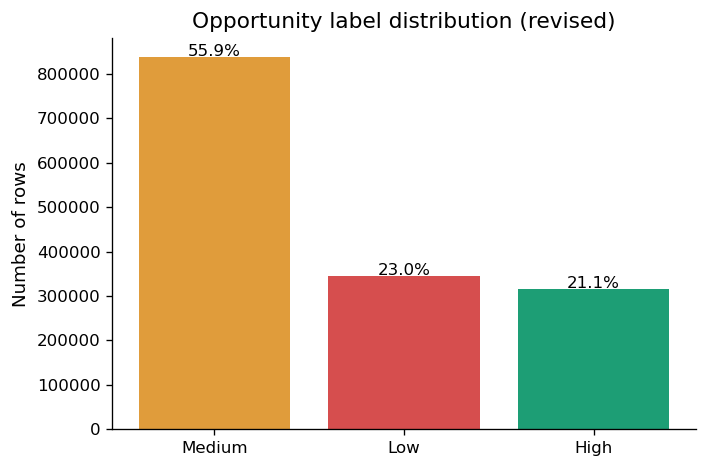

In [18]:
label_map  = {0:'Low', 1:'Medium', 2:'High'}
label_dist = world['opportunity_label'].map(label_map).value_counts()
colors     = {'Low':'#d64e4e','Medium':'#e09c3b','High':'#1d9e75'}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(label_dist.index, label_dist.values,
              color=[colors[l] for l in label_dist.index])
for bar, val in zip(bars, label_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{100*val/len(world):.1f}%', ha='center', fontsize=10)
ax.set_title('Opportunity label distribution (revised)')
ax.set_ylabel('Number of rows')
plt.tight_layout()
plt.show()

#### Check distribution of the target variable by sector

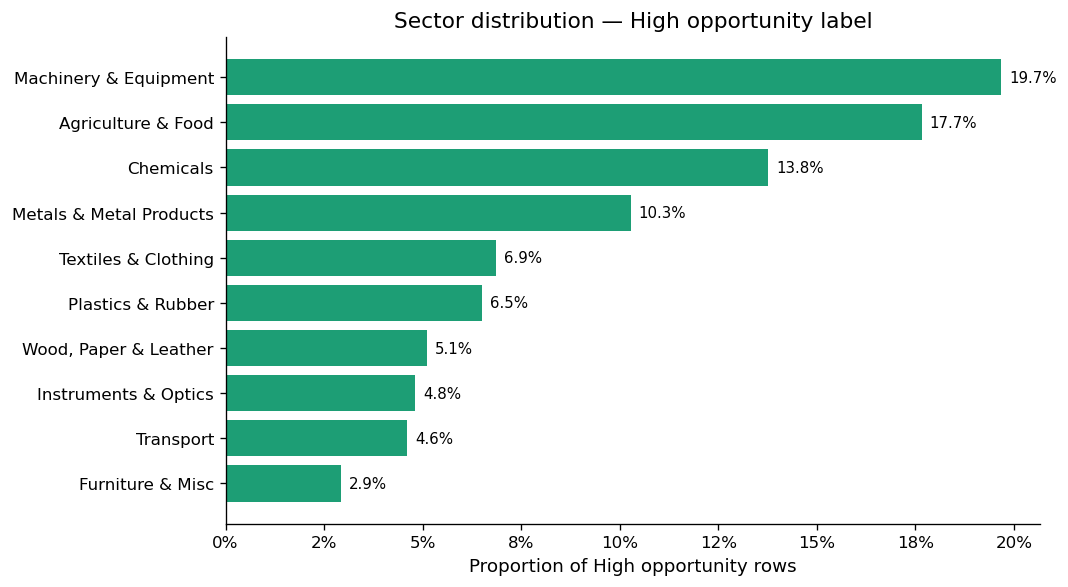

In [19]:
sector_dist = world[world['opportunity_label'] == 2]['sector'].value_counts(normalize=True).head(10)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(sector_dist.index[::-1], sector_dist.values[::-1], color='#1d9e75')
ax.set_xlabel('Proportion of High opportunity rows')
ax.set_title('Sector distribution — High opportunity label')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
for i, (val, name) in enumerate(zip(sector_dist.values[::-1], sector_dist.index[::-1])):
    ax.text(val + 0.002, i, f'{val:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

The High opportunity class is well distributed across sectors with no single sector dominating .

### 3.9 Final column order and save

In [20]:
cols = [
    'year','importer','product',
    'total_value','total_qty',
    'algeria_export_v','algeria_export_q','algeria_present',
    'algeria_market_share','demand_gap_v','demand_gap_relative','market_penetration_ratio',
    'world_demand_growth','world_demand_growth_3y','algeria_export_growth',
    'global_demand_v','global_demand_index','global_demand_growth',
    'algeria_product_count','algeria_total_export_v','algeria_market_count','algeria_global_export_v',
    'is_covid_year',
    'gdp_usd','gdp_per_capita','gdp_growth_rate','population','trade_openness','inflation_rate',
    'distance_km','distance_capitals','distance_weighted',
    'shares_border','common_language_off','common_language_eth','colonial_link','common_colonizer',
    'is_landlocked','continent','official_language','main_spoken_language',
    'hs2_chapter','hs_section','sector',
    'opportunity_label',
]
cols = [c for c in cols if c in world.columns]
world = world[cols].reset_index(drop=True)
world.to_csv(OUTPUT_FILE, index=False)
print(f'Saved: {OUTPUT_FILE}  |  Shape: {world.shape}')
world.head(5)

Saved: ../data/world_trade_data_features.csv  |  Shape: (1501178, 45)


,year,importer,product,total_value,total_qty,algeria_export_v,algeria_export_q,algeria_present,algeria_market_share,demand_gap_v,demand_gap_relative,market_penetration_ratio,world_demand_growth,world_demand_growth_3y,algeria_export_growth,global_demand_v,global_demand_index,global_demand_growth,algeria_product_count,algeria_total_export_v,...,gdp_growth_rate,population,trade_openness,inflation_rate,distance_km,distance_capitals,distance_weighted,shares_border,common_language_off,common_language_eth,colonial_link,common_colonizer,is_landlocked,continent,official_language,main_spoken_language,hs2_chapter,hs_section,sector,opportunity_label
0,2012,24,0101,621.7000,58.6300,0.0000,0.0000,0,0.0000,621.7000,1.0000,0.0000,NaN,NaN,NaN,2090553.2300,0.0015,NaN,15.0000,792.2960,...,8.5031,25177394.0000,81.9395,10.2779,5194.2440,5194.2440,5223.2270,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Africa,Portuguese,Portuguese,1,0,Agriculture & Food,1
1,2013,24,0101,370.1930,30.3210,0.0000,0.0000,0,0.0000,370.1930,1.0000,0.0000,-0.4045,-0.4045,NaN,2294963.3820,0.0015,0.0978,16.0000,438.3430,...,4.8831,26165620.0000,77.3498,8.7778,5194.2440,5194.2440,5223.2270,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Africa,Portuguese,Portuguese,1,0,Agriculture & Food,0
2,2014,24,0101,480.7670,32.7470,0.0000,0.0000,0,0.0000,480.7670,1.0000,0.0000,0.2987,-0.0529,NaN,2360790.4530,0.0017,0.0287,24.0000,616.5260,...,4.6557,27160769.0000,69.5801,7.2804,5194.2440,5194.2440,5223.2270,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Africa,Portuguese,Portuguese,1,0,Agriculture & Food,0
3,2015,24,0101,61.5320,3.8680,0.0000,0.0000,0,0.0000,61.5320,1.0000,0.0000,-0.8720,-0.3260,NaN,2522301.7070,0.0033,0.0684,16.0000,1184.2200,...,0.7632,28157798.0000,54.9794,9.3560,5194.2440,5194.2440,5223.2270,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Africa,Portuguese,Portuguese,1,0,Agriculture & Food,0
4,2016,24,0101,61.7520,8.2650,0.0000,0.0000,0,0.0000,61.7520,1.0000,0.0000,0.0036,-0.1899,NaN,2554796.2710,0.0037,0.0129,37.0000,8478.4750,...,-1.7005,29183070.0000,47.0156,30.6944,5194.2440,5194.2440,5223.2270,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Africa,Portuguese,Portuguese,1,0,Agriculture & Food,0


---
## 4. Feature reduction

We perform two complementary steps:

1. **Correlation analysis** — identify and remove features that are near-perfect linear duplicates of each other. Keeping both would waste model capacity and introduce multicollinearity.
2. **PCA** — project the remaining numeric features into uncorrelated principal components for use in clustering. PCA is not applied to the classification or forecasting datasets — those benefit from interpretable original features.

### 4.1 Correlation analysis and redundant feature removal

We compute the Pearson correlation matrix on all numeric model features and flag any pair with |correlation| > 0.85. For each such pair we drop the feature that carries less unique information (usually the derived one if the base is already present).

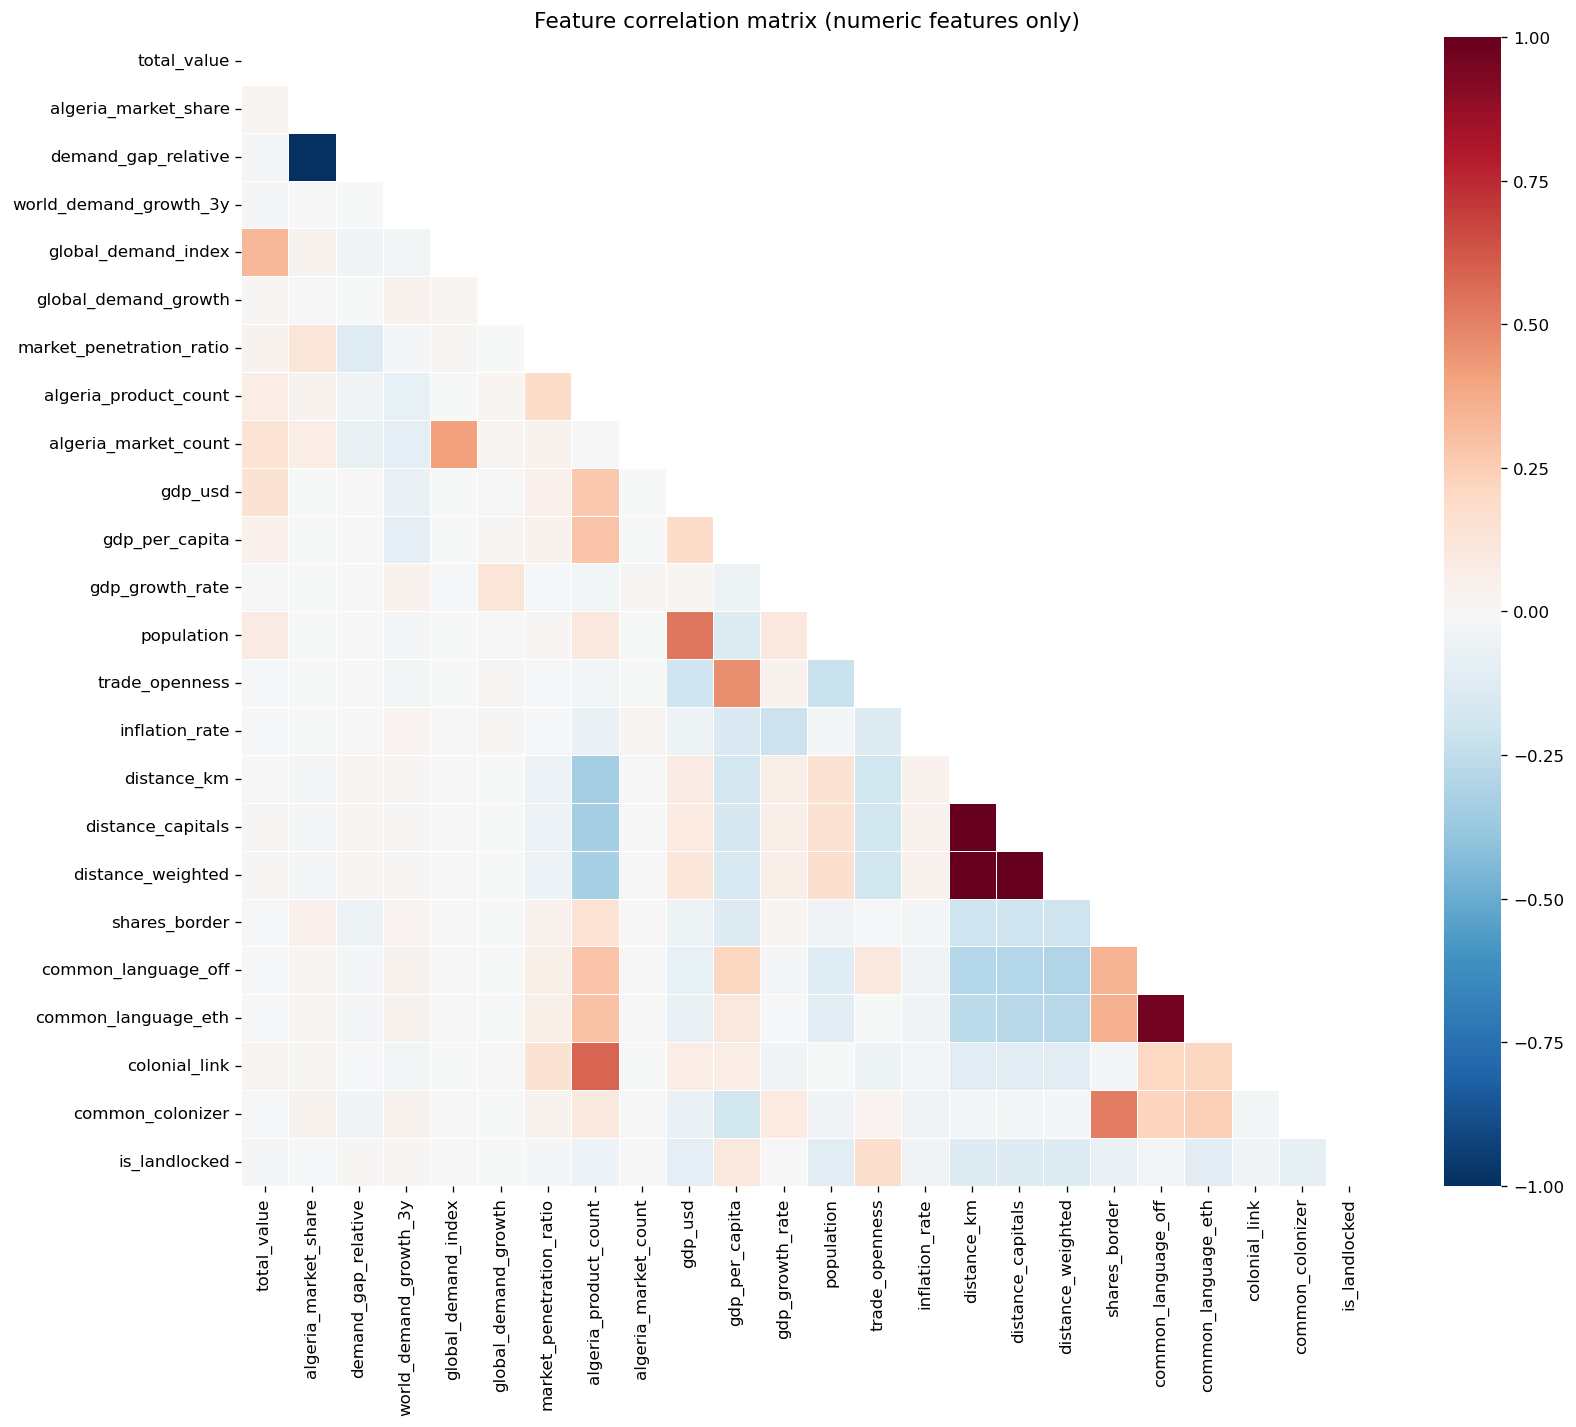

In [21]:
numeric_features = [
    'total_value','algeria_market_share','demand_gap_relative',
    'world_demand_growth_3y','global_demand_index','global_demand_growth',
    'market_penetration_ratio','algeria_product_count','algeria_market_count',
    'gdp_usd','gdp_per_capita','gdp_growth_rate',
    'population','trade_openness','inflation_rate',
    'distance_km','distance_capitals','distance_weighted',
    'shares_border','common_language_off','common_language_eth',
    'colonial_link','common_colonizer','is_landlocked',
] # we excluded numeric features that are categorical in real meaning (like year , importer , product...) also the target variable.

corr_matrix = world[numeric_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3, ax=ax)
ax.set_title('Feature correlation matrix (numeric features only)')
plt.tight_layout()
plt.show()

In [22]:
# Identify all pairs with |correlation| > 0.85
upper = corr_matrix.abs().where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0':'feature_A','level_1':'feature_B', 0:'correlation'})
    .query('correlation > 0.85')
    .sort_values('correlation', ascending=False)
    .reset_index(drop=True)
)
print(f'Pairs with |correlation| > 0.85:')
high_corr_pairs

Pairs with |correlation| > 0.85:


,feature_A,feature_B,correlation
0,demand_gap_relative,algeria_market_share,1.0000
1,distance_capitals,distance_km,0.9995
2,distance_weighted,distance_capitals,0.9984
3,distance_weighted,distance_km,0.9979
4,common_language_eth,common_language_off,0.9676


Based on the correlation analysis, we drop the following redundant features:

- **`demand_gap_relative`** — mathematically defined as `1 - algeria_market_share`, so perfectly correlated. The model only needs one of them; we keep `algeria_market_share` as it is more interpretable.
- **`distance_capitals` and `distance_weighted`** — highly correlated with `distance_km` (simple centroid distance). We keep `distance_km` as the standard gravity model measure.



In [23]:
features_to_drop = [
    'demand_gap_relative',       # = 1 - algeria_market_share (perfect linear dependency)
    'distance_capitals',         # redundant with distance_km
    'distance_weighted',         # redundant with distance_km
]

model_features = [f for f in numeric_features if f not in features_to_drop]
print(f'Features before drop : {len(numeric_features)}')
print(f'Features after drop  : {len(model_features)}')
print(f'Retained features    : {model_features}')

Features before drop : 24
Features after drop  : 21
Retained features    : ['total_value', 'algeria_market_share', 'world_demand_growth_3y', 'global_demand_index', 'global_demand_growth', 'market_penetration_ratio', 'algeria_product_count', 'algeria_market_count', 'gdp_usd', 'gdp_per_capita', 'gdp_growth_rate', 'population', 'trade_openness', 'inflation_rate', 'distance_km', 'shares_border', 'common_language_off', 'common_language_eth', 'colonial_link', 'common_colonizer', 'is_landlocked']


Remaining pairs > 0.85 after drop: 1
                       A                    B   corr
152  common_language_eth  common_language_off 0.9676


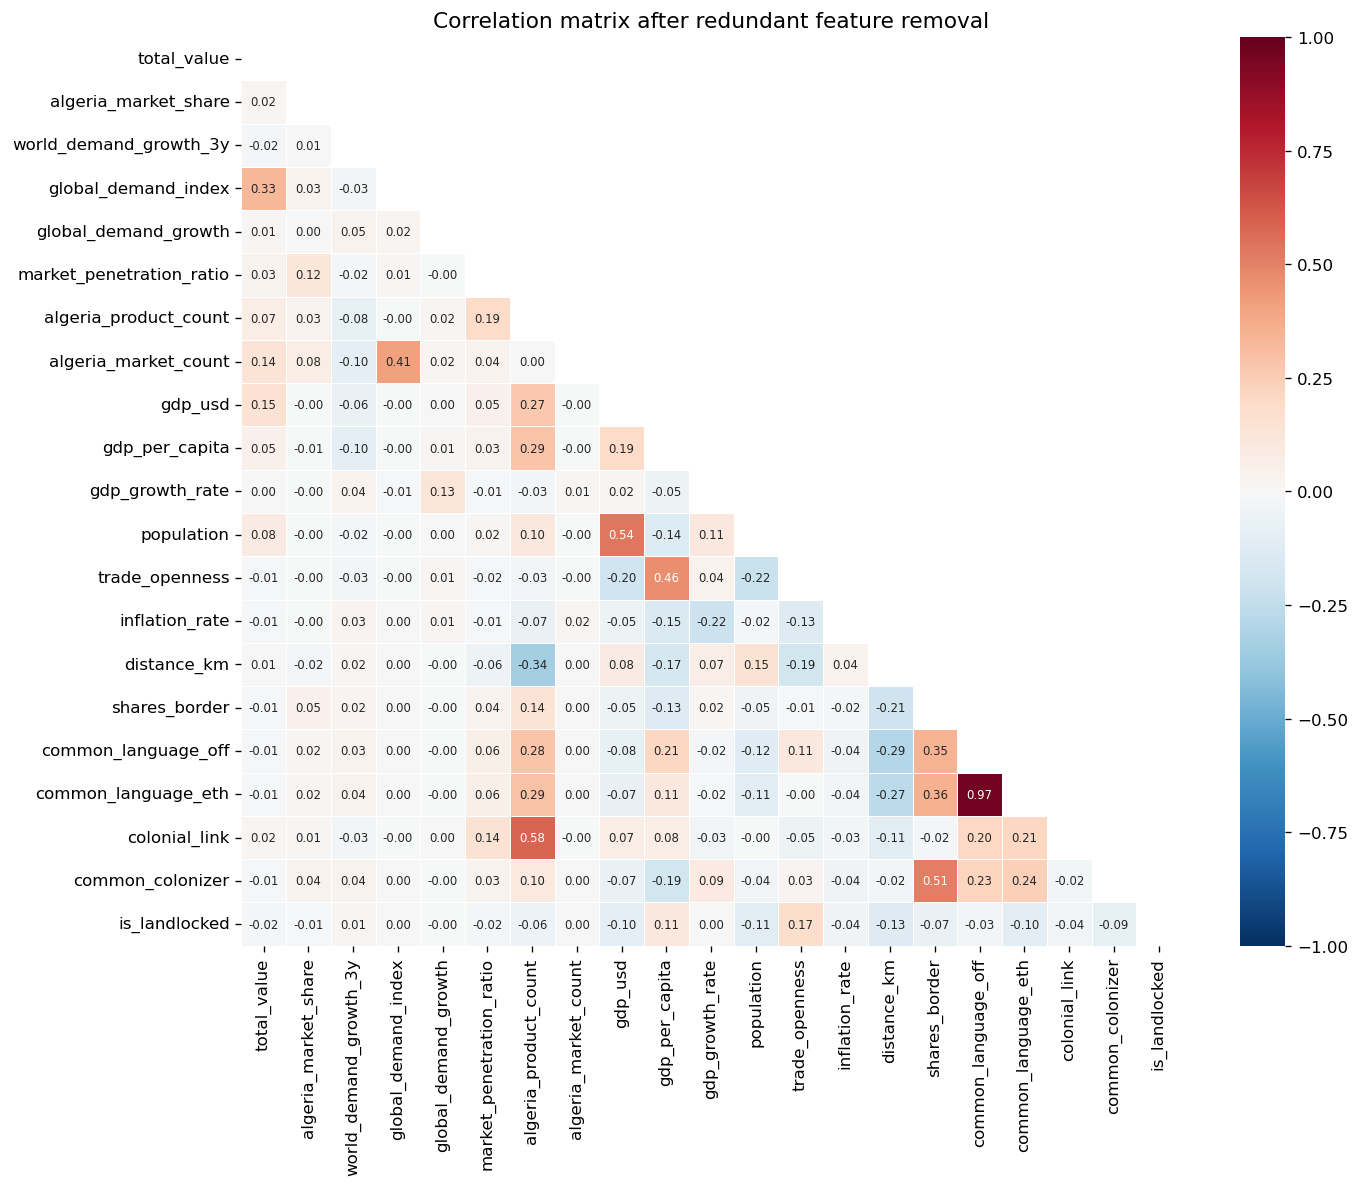

In [24]:
# Verify no remaining pair exceeds 0.85
corr_clean = world[model_features].corr()
upper_clean = corr_clean.abs().where(np.tril(np.ones(corr_clean.shape), k=-1).astype(bool))
remaining_high = upper_clean.stack().reset_index()
remaining_high.columns = ['A','B','corr']
remaining_high = remaining_high[remaining_high['corr'] > 0.85]

print(f'Remaining pairs > 0.85 after drop: {len(remaining_high)}')
if len(remaining_high) > 0:
    print(remaining_high)

fig, ax = plt.subplots(figsize=(12, 10))
mask2 = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(corr_clean, mask=mask2, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.3, ax=ax)
ax.set_title('Correlation matrix after redundant feature removal')
plt.tight_layout()
plt.show()

#### Drop redundant features and save the final dataset for classification

In [25]:
final_cols = [c for c in world.columns if c not in features_to_drop]
world = world[final_cols].reset_index(drop=True)
world.to_csv(OUTPUT_FILE, index=False)
print(f'Saved: {OUTPUT_FILE}  |  Shape: {world.shape}')


Saved: ../data/world_trade_data_features.csv  |  Shape: (1501178, 42)


### 4.2 Principal Component Analysis (PCA)

PCA is applied to the cleaned numeric feature set for use specifically in **clustering** — K-Means and DBSCAN perform better in lower-dimensional space where Euclidean distance is meaningful.

Steps:
1. Impute any remaining NaN with column median (growth features have NaN for year 1)
2. Standardise all features to zero mean and unit variance 
3. Fit PCA and determine how many components explain 90% of variance
4. Save the PCA-transformed dataset alongside the original

In [26]:
X = world[model_features].copy()

# Impute remaining NaN with column median before scaling
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape : {X_scaled.shape}')
print(f'Any NaN after impute : {np.isnan(X_scaled).any()}')

Feature matrix shape : (1501178, 21)
Any NaN after impute : False


Components for 90% variance: 16
Components for 95% variance: 17


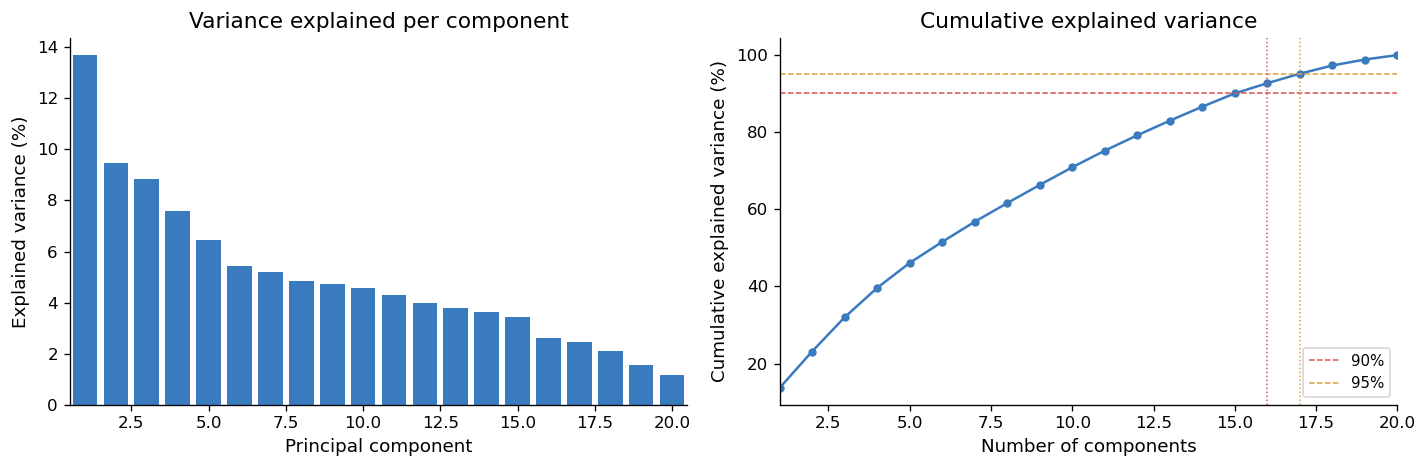

In [27]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained        = pca_full.explained_variance_ratio_
cumulative       = np.cumsum(explained)
n_components_90  = np.argmax(cumulative >= 0.90) + 1
n_components_95  = np.argmax(cumulative >= 0.95) + 1

print(f'Components for 90% variance: {n_components_90}')
print(f'Components for 95% variance: {n_components_95}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained)+1), explained * 100, color='#3a7abf')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Variance explained per component')
axes[0].set_xlim(0.5, min(20, len(explained)) + 0.5)

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker='o', markersize=4, color='#3a7abf')
axes[1].axhline(90, color='#d64e4e', linewidth=0.9, linestyle='--', label='90%')
axes[1].axhline(95, color='#e09c3b', linewidth=0.9, linestyle='--', label='95%')
axes[1].axvline(n_components_90, color='#d64e4e', linewidth=0.9, linestyle=':')
axes[1].axvline(n_components_95, color='#e09c3b', linewidth=0.9, linestyle=':')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance (%)')
axes[1].set_title('Cumulative explained variance')
axes[1].legend(fontsize=9)
axes[1].set_xlim(1, min(20, len(cumulative)))

plt.tight_layout()
plt.show()

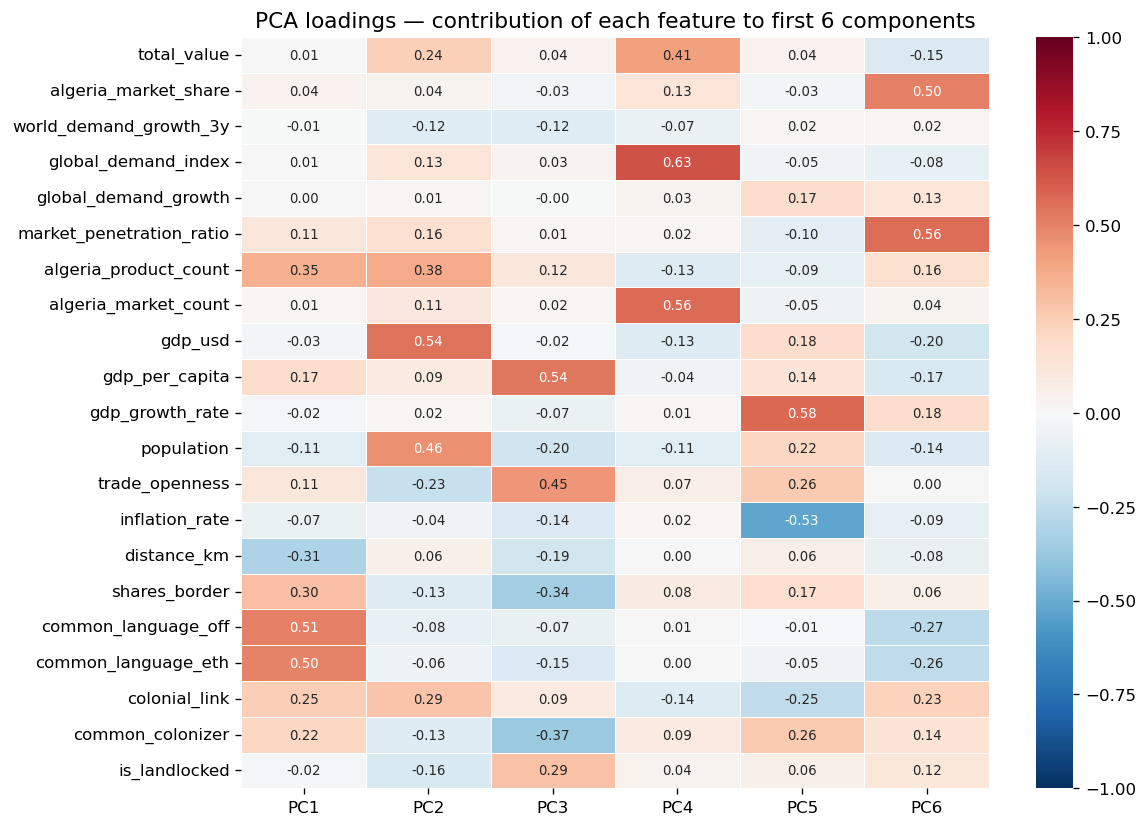

,PC1,PC2,PC3,PC4,PC5,PC6
total_value,0.0070,0.2390,0.0410,0.4140,0.0410,-0.1550
algeria_market_share,0.0410,0.0370,-0.0330,0.1260,-0.0290,0.5020
world_demand_growth_3y,-0.0060,-0.1190,-0.1240,-0.0690,0.0210,0.0180
global_demand_index,0.0050,0.1310,0.0250,0.6330,-0.0460,-0.0800
global_demand_growth,0.0030,0.0110,-0.0010,0.0330,0.1740,0.1290
market_penetration_ratio,0.1120,0.1590,0.0140,0.0190,-0.1030,0.5580
algeria_product_count,0.3520,0.3810,0.1170,-0.1290,-0.0890,0.1610
algeria_market_count,0.0080,0.1080,0.0230,0.5650,-0.0510,0.0390
gdp_usd,-0.0310,0.5440,-0.0180,-0.1280,0.1830,-0.1950
gdp_per_capita,0.1720,0.0920,0.5360,-0.0440,0.1400,-0.1700


In [28]:
# Show which original features contribute most to the first few components
loadings = pd.DataFrame(
    pca_full.components_[:6].T,
    index=model_features,
    columns=[f'PC{i+1}' for i in range(6)]
).round(3)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loadings, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8}, linewidths=0.3, ax=ax)
ax.set_title('PCA loadings — contribution of each feature to first 6 components')
plt.tight_layout()
plt.show()

loadings

In [29]:
# Fit final PCA with n_components_90 and save transformed dataset
pca_final = PCA(n_components=n_components_90, random_state=42)
X_pca     = pca_final.fit_transform(X_scaled)

pca_cols  = [f'PC{i+1}' for i in range(n_components_90)]
df_pca    = pd.DataFrame(X_pca, columns=pca_cols)

# Attach key identifiers and the target label
df_pca['year']              = world['year'].values
df_pca['importer']          = world['importer'].values
df_pca['product']           = world['product'].values
df_pca['sector']            = world['sector'].values
df_pca['algeria_present']   = world['algeria_present'].values
df_pca['opportunity_label'] = world['opportunity_label'].values

df_pca.to_csv(PCA_FILE, index=False)
print(f'PCA dataset saved: {PCA_FILE}')
print(f'Shape: {df_pca.shape}')
print(f'Variance retained: {pca_final.explained_variance_ratio_.sum()*100:.1f}%')
df_pca.head(3)

PCA dataset saved: ../data/world_trade_data_pca.csv
Shape: (1501178, 22)
Variance retained: 92.6%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,year,importer,product,sector,algeria_present,opportunity_label
0,-0.8849,-0.3263,-0.3841,-0.2819,0.3630,0.4357,0.2908,-0.6392,-0.0644,-0.0172,0.0452,-0.0647,0.4002,-0.1197,0.9847,-0.1186,2012,24,0101,Agriculture & Food,0,1
1,-0.8649,-0.2306,-0.2932,-0.1403,0.0090,0.3629,0.1003,-0.7042,-0.1177,0.5507,0.1100,-0.0425,0.5732,-0.2713,0.4209,0.0260,2013,24,0101,Agriculture & Food,0,0
2,-0.8269,-0.1884,-0.3622,-0.2020,-0.0800,0.3434,0.0679,-0.6167,-0.1209,0.1156,0.0590,-0.1241,0.4210,-0.3382,0.4173,-0.0791,2014,24,0101,Agriculture & Food,0,0


---
## 5. Exploratory Data Analysis (EDA)

We analyse the dataset across five dimensions:
1. Algeria's export profile over time
2. Sector composition
3. Global demand trends
4. Opportunity landscape
5. Feature distributions

### 5.1 Algeria export profile over time

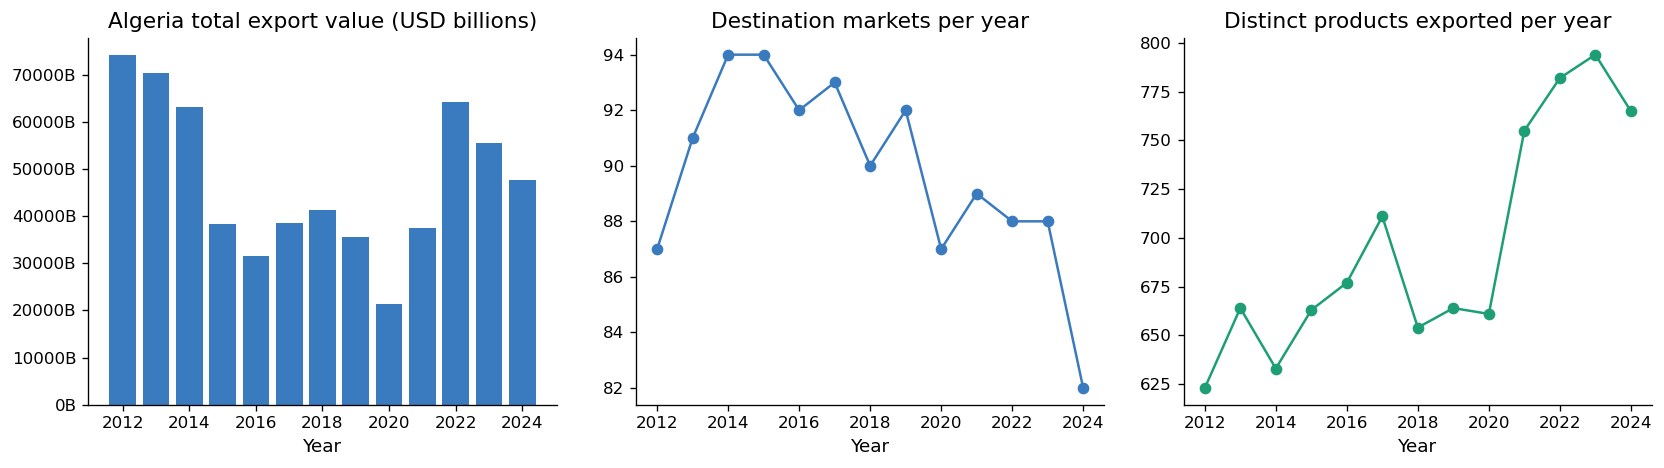

In [30]:
alg_yearly = (
    alg.groupby('year')
    .agg(total_v=('total_value','sum'),
         n_markets=('importer','nunique'),
         n_products=('product','nunique'))
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(alg_yearly['year'], alg_yearly['total_v']/1e3, color='#3a7abf')
axes[0].set_title('Algeria total export value (USD billions)')
axes[0].set_xlabel('Year')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}B'))

axes[1].plot(alg_yearly['year'], alg_yearly['n_markets'], marker='o', color='#3a7abf')
axes[1].set_title('Destination markets per year')
axes[1].set_xlabel('Year')

axes[2].plot(alg_yearly['year'], alg_yearly['n_products'], marker='o', color='#1d9e75')
axes[2].set_title('Distinct products exported per year')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

### 5.2 Export composition by sector

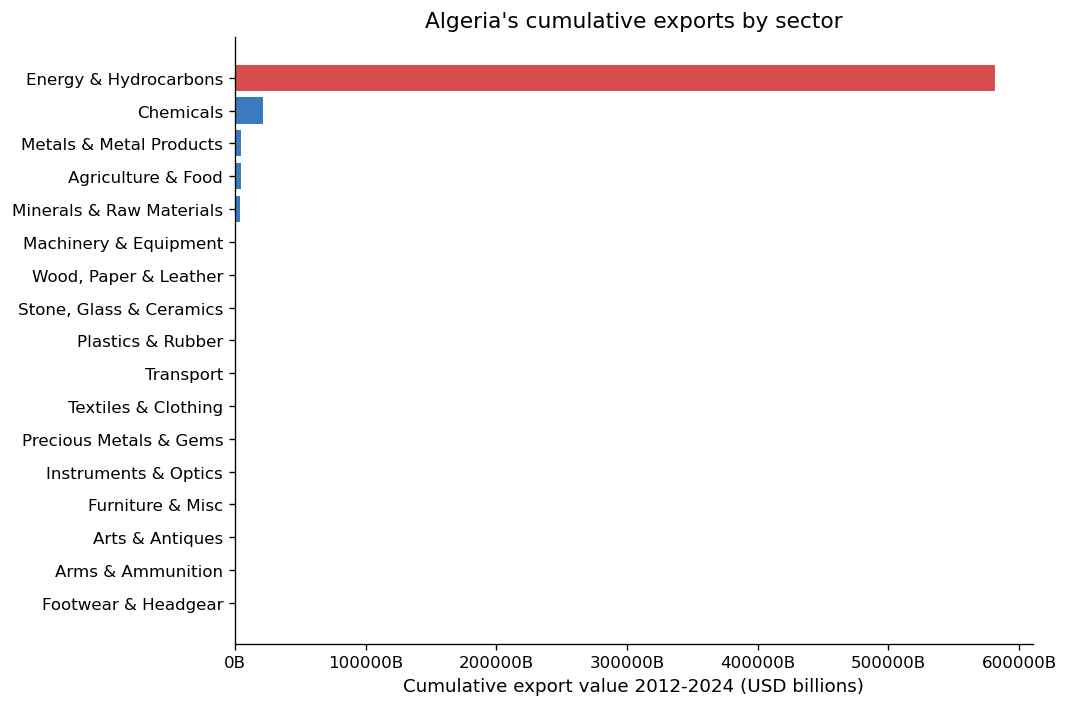

In [31]:
alg_enriched = alg.copy()

# Keep Algeria sector when present; backfill from world mapping only if missing.
if ('sector' not in alg_enriched.columns) or alg_enriched['sector'].isna().any():
    sector_map = (
        world[['year', 'importer', 'product', 'sector']]
        .drop_duplicates()
        .rename(columns={'sector': 'sector_world'})
    )
    alg_enriched = alg_enriched.merge(
        sector_map,
        on=['year', 'importer', 'product'],
        how='left'
    )

    if 'sector' in alg_enriched.columns:
        alg_enriched['sector'] = alg_enriched['sector'].fillna(alg_enriched['sector_world'])
    else:
        alg_enriched['sector'] = alg_enriched['sector_world']

    alg_enriched = alg_enriched.drop(columns=['sector_world'])

alg_sector = (
    alg_enriched.groupby('sector')['total_value']
    .sum().sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#d64e4e' if 'Energy' in s else '#3a7abf' for s in alg_sector.index]
ax.barh(alg_sector.index, alg_sector.values / 1e3, color=bar_colors)
ax.set_xlabel('Cumulative export value 2012-2024 (USD billions)')
ax.set_title("Algeria's cumulative exports by sector")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
plt.tight_layout()
plt.show()

### 5.3 Non-hydrocarbon export top markets

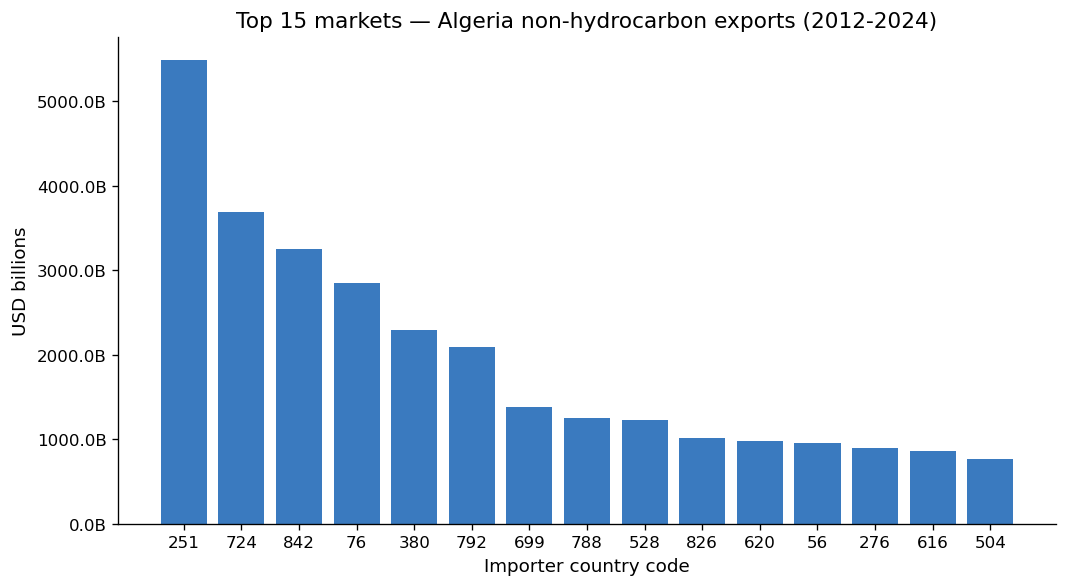

In [32]:
if ('alg_enriched' not in globals()) or ('sector' not in alg_enriched.columns):
    alg_enriched = alg.copy()
    if ('sector' not in alg_enriched.columns) or alg_enriched['sector'].isna().any():
        sector_map = (
            world[['year', 'importer', 'product', 'sector']]
            .drop_duplicates()
            .rename(columns={'sector': 'sector_world'})
        )
        alg_enriched = alg_enriched.merge(
            sector_map,
            on=['year', 'importer', 'product'],
            how='left'
        )

        if 'sector' in alg_enriched.columns:
            alg_enriched['sector'] = alg_enriched['sector'].fillna(alg_enriched['sector_world'])
        else:
            alg_enriched['sector'] = alg_enriched['sector_world']

        alg_enriched = alg_enriched.drop(columns=['sector_world'])

non_hydro = alg_enriched[alg_enriched['sector'] != 'Energy & Hydrocarbons']
top_markets = (
    non_hydro.groupby('importer')['total_value']
    .sum().sort_values(ascending=False).head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(top_markets.index.astype(str), top_markets.values / 1e3, color='#3a7abf')
ax.set_xlabel('Importer country code')
ax.set_ylabel('USD billions')
ax.set_title('Top 15 markets — Algeria non-hydrocarbon exports (2012-2024)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
plt.tight_layout()
plt.show()

### 5.4 Global demand trends by sector (indexed to 2012)

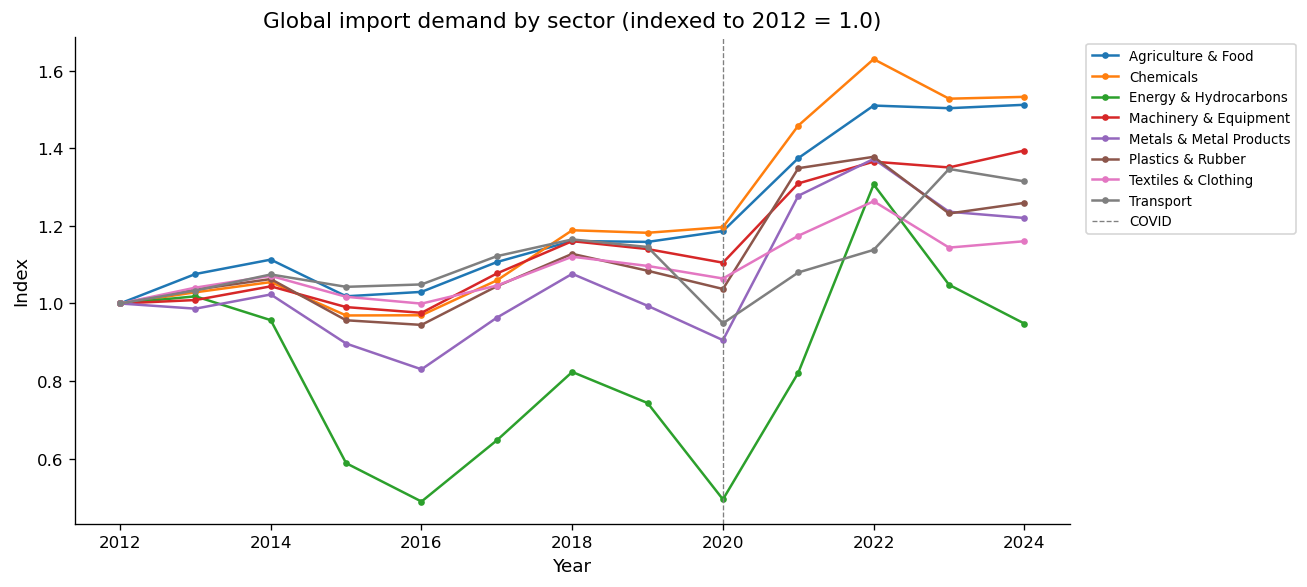

In [33]:
sector_yearly = world.groupby(['year','sector'])['total_value'].sum().reset_index()
top_sectors   = (
    sector_yearly.groupby('sector')['total_value']
    .sum().sort_values(ascending=False).head(8).index.tolist()
)
pivot      = sector_yearly[sector_yearly['sector'].isin(top_sectors)].pivot(
    index='year', columns='sector', values='total_value'
)
pivot_norm = pivot.div(pivot.iloc[0])

fig, ax = plt.subplots(figsize=(11, 5))
for col in pivot_norm.columns:
    ax.plot(pivot_norm.index, pivot_norm[col], marker='o', markersize=3, label=col)
ax.axvline(2020, color='gray', linewidth=0.8, linestyle='--', label='COVID')
ax.set_title('Global import demand by sector (indexed to 2012 = 1.0)')
ax.set_xlabel('Year')
ax.set_ylabel('Index')
ax.legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.5 Top high-opportunity pairs in 2024

In [34]:
top_opps = (
    world[(world['year']==2024) & (world['opportunity_label']==2)]
    [['importer','product','sector','total_value','demand_gap_v',
      'algeria_market_share','world_demand_growth_3y','global_demand_index']]
    .sort_values('demand_gap_v', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_opps.columns = ['importer','product','sector','world imports (M)',
                    'demand gap (M)','alg share','demand growth 3y','demand index']
top_opps.round(4)

,importer,product,sector,world imports (M),demand gap (M),alg share,demand growth 3y,demand index
0,156,2709,Energy & Hydrocarbons,294190760.9460,294190760.9460,0.0000,0.0951,1.0000
1,842,8703,Transport,215906371.4120,215906371.4120,0.0000,0.1380,0.7467
2,344,8542,Machinery & Equipment,175426634.4170,175426634.4170,0.0000,0.0281,0.5267
3,842,2709,Energy & Hydrocarbons,164753273.6110,164418944.1410,0.0020,0.1076,1.0000
4,699,2709,Energy & Hydrocarbons,141314363.7750,140481456.5750,0.0059,0.1634,1.0000
5,842,8471,Machinery & Equipment,113261050.2910,113261050.2910,0.0000,0.0351,0.3430
6,842,8517,Machinery & Equipment,108051187.9490,108051187.9490,0.0000,0.0125,0.5222
7,842,3002,Chemicals,104070035.7680,104070035.7680,0.0000,0.2307,0.2860
8,842,3004,Chemicals,92558925.0330,92558925.0330,0.0000,0.0494,0.3838
9,757,7108,Precious Metals & Gems,92179013.2690,92179013.2690,0.0000,0.0473,0.3835


### 5.6 Demand gap by continent (high-opportunity rows, 2024)

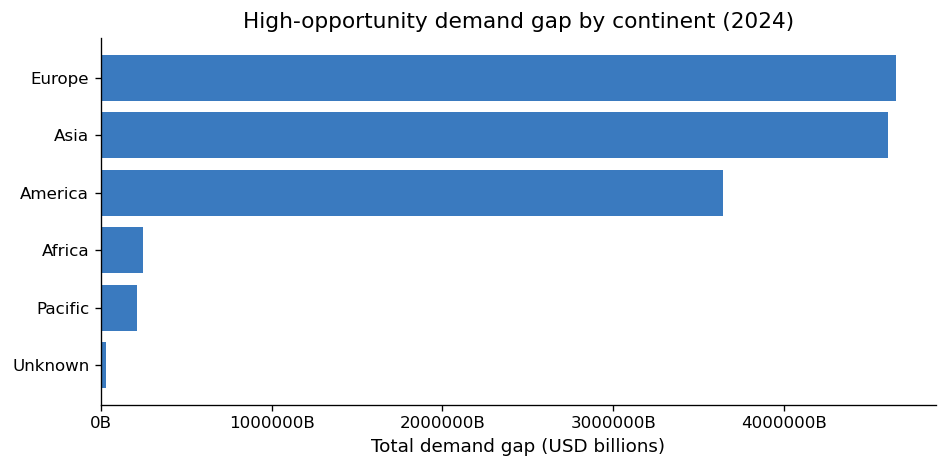

In [35]:
gap_continent = (
    world[(world['opportunity_label']==2) & (world['year']==2024)]
    .groupby('continent')['demand_gap_v']
    .sum().sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(gap_continent.index, gap_continent.values/1e3, color='#3a7abf')
ax.set_xlabel('Total demand gap (USD billions)')
ax.set_title('High-opportunity demand gap by continent (2024)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}B'))
plt.tight_layout()
plt.show()

### 5.7 Algeria market share distribution (2024, markets where present)

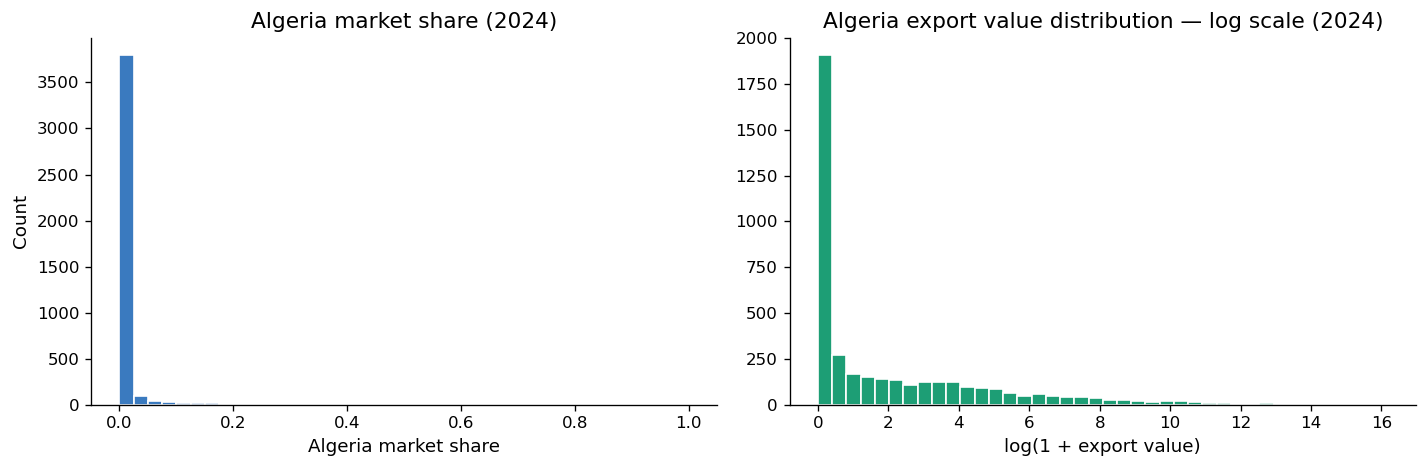

In [36]:
present_2024 = world[(world['algeria_present']==1) & (world['year']==2024)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(present_2024['algeria_market_share'], bins=40, color='#3a7abf', edgecolor='white')
axes[0].set_xlabel('Algeria market share')
axes[0].set_ylabel('Count')
axes[0].set_title('Algeria market share (2024)')

axes[1].hist(np.log1p(present_2024['algeria_export_v']), bins=40, color='#1d9e75', edgecolor='white')
axes[1].set_xlabel('log(1 + export value)')
axes[1].set_title('Algeria export value distribution — log scale (2024)')

plt.tight_layout()
plt.show()

### 5.8 PCA — first two components coloured by opportunity label

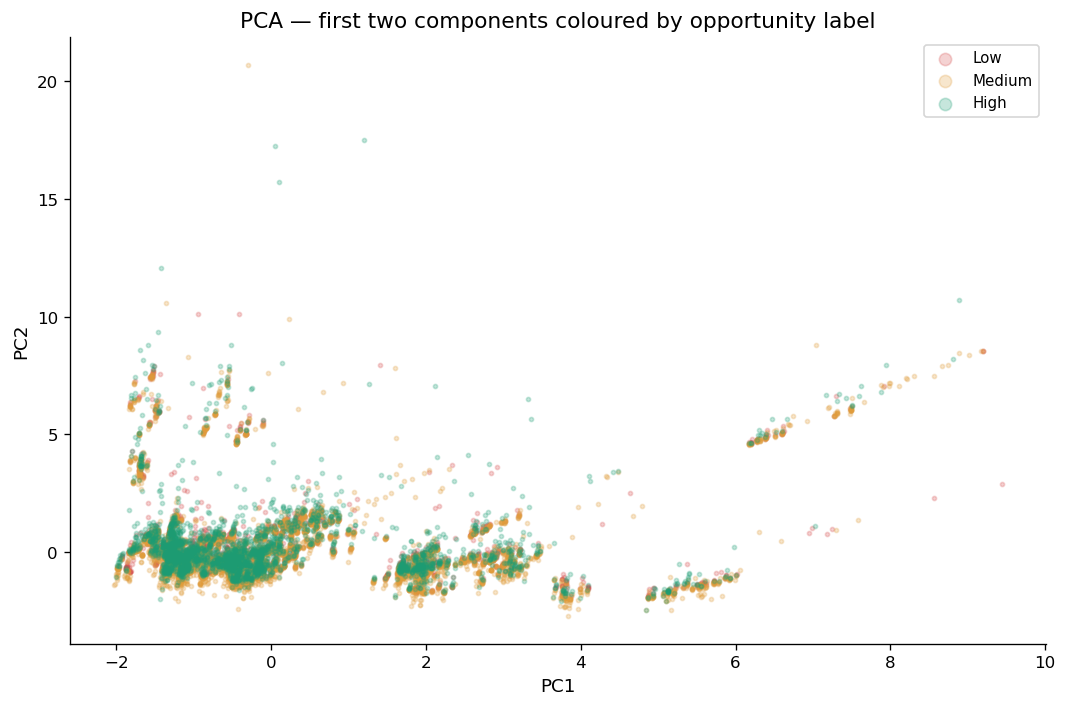

In [37]:
# Sample 15,000 rows for readability
sample = df_pca.sample(15000, random_state=42)
color_map = {0:'#d64e4e', 1:'#e09c3b', 2:'#1d9e75'}
label_map  = {0:'Low', 1:'Medium', 2:'High'}

fig, ax = plt.subplots(figsize=(9, 6))
for lbl, grp in sample.groupby('opportunity_label'):
    ax.scatter(grp['PC1'], grp['PC2'],
               c=color_map[lbl], label=label_map[lbl],
               alpha=0.25, s=6, rasterized=True)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA — first two components coloured by opportunity label')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation of teh plot

PC1 primarily captures market size and economic weight of the importer — larger economies
sit further right. The dense cluster on the left (PC1 < 2) contains the majority of rows where
most country-product pairs share similar characteristics: small market size and low Algeria presence.

The outliers spreading right (PC1 > 6) are almost the two 
largest trading partners (France and the USA) pushed out by their high GDP and import volumes.

The three classes overlap heavily in 2D because PCA optimises for variance, not class
separability.

It does not mean our features are weak. just cause  the opportunity signal is a combination of multiple features working together  but the classification model uses all components together, where separation is clearer.

### 5.9 Engineered feature summary statistics

In [38]:
summary_cols = [
    'algeria_market_share','demand_gap_v','market_penetration_ratio',
    'world_demand_growth','world_demand_growth_3y',
    'global_demand_index','global_demand_growth',
    'algeria_product_count','algeria_market_count',
]
world[summary_cols].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
algeria_market_share,1501178.0000,0.0003,0.0115,0.0000,0.0000,0.0000,0.0000,1.0000
demand_gap_v,1501178.0000,151225.4477,1713012.4284,0.0000,790.8570,6717.3045,42214.4780,333316419.7740
market_penetration_ratio,1501178.0000,0.0060,0.0655,0.0000,0.0000,0.0000,0.0000,1.0000
world_demand_growth,1382657.0000,0.3497,1.5725,-1.0000,-0.1861,0.0239,0.2779,10.0000
world_demand_growth_3y,1382657.0000,0.3678,1.0507,-1.0000,-0.0347,0.0773,0.2819,10.0000
global_demand_index,1501178.0000,0.0140,0.0535,0.0000,0.0009,0.0030,0.0099,1.0000
global_demand_growth,1386551.0000,0.0303,0.2081,-0.9328,-0.0612,0.0174,0.0913,10.0000
algeria_product_count,1501178.0000,36.5089,56.1724,0.0000,4.0000,13.0000,41.0000,476.0000
algeria_market_count,1501178.0000,2.9151,5.1598,0.0000,0.0000,1.0000,4.0000,63.0000


---
## 6. Output summary

Two files are produced by this notebook:

| File | Purpose | Shape |
|---|---|---|
| `world_trade_data_features.csv` | Full feature set (excluding correlated ones) to use for classification and forecasting | ~1.5M × 42 |
| `world_trade_data_pca.csv` | PCA-reduced ( for clustering ) | ~1.5M × (n_components + 6) |

**Retained model features** (after redundant feature removal):
- Trade: `total_value`, `algeria_market_share`, `world_demand_growth_3y`, `global_demand_index`, `global_demand_growth`, `market_penetration_ratio`, `algeria_product_count`, `algeria_market_count`
- Economic: `gdp_usd`, `gdp_per_capita`, `gdp_growth_rate`, `population`, `trade_openness`, `inflation_rate`
- Gravity: `distance_km`, `shares_border`, `common_language_off`, `colonial_link`, `is_landlocked`


In [39]:
print(f'Features CSV  : {OUTPUT_FILE}')
print(f'PCA CSV       : {PCA_FILE}')
print(f'Features shape: {world.shape}')
print(f'PCA shape     : {df_pca.shape}')
print(f'Label dist    : {world["opportunity_label"].value_counts().sort_index().to_dict()}')
print(f'Retained feats: {len(model_features)}')
print(f'PCA components: {n_components_90}  (90% variance)')

Features CSV  : ../data/world_trade_data_features.csv
PCA CSV       : ../data/world_trade_data_pca.csv
Features shape: (1501178, 42)
PCA shape     : (1501178, 22)
Label dist    : {0: 345998, 1: 838681, 2: 316499}
Retained feats: 21
PCA components: 16  (90% variance)


## Next steps recommendations and guide based on the EDA insights and feature engineering:

### Clustering
**Goal:** Group countries by import demand pattern and group products by global demand trend.
**Input file:** `world_trade_data_pca.csv`
**Steps:**
1. Cap extreme PC values at ±3 standard deviations to prevent outlier dominance
2. Use the Elbow method and Silhouette score to find the optimal number of clusters K (try K = 3 to 10)
3. Run K-Means on the full PCA matrix 
4. Run a separate clustering on countries and a separate one on products
5. Evaluate using Silhouette Score and Davies-Bouldin Index as specified in the project spec
6. Attach the cluster label back to the main dataset as a new feature for the classifier

### Classification
**Goal:** Predict `opportunity_label` (0=Low, 1=Medium, 2=High) for each (importer, product) pair.
**Input file:** `world_trade_data_features.csv`
**Steps:**
1. Use only the retained features listed in section 4.1 — do not include key columns (`year`, `importer`, `product`, `sector`) as model inputs
2. Split by year: train on 2012–2021, validate on 2022, test on 2023–2024 — never use random split on time series data
3. Handle class imbalance with `scale_pos_weight` in XGBoost or `class_weight='balanced'` in Random Forest
4. Evaluate with F1-score per class, Precision, Recall — not accuracy (misleading with imbalanced classes)
5. Use SHAP values to interpret which features drive High opportunity predictions

### Forecasting
**Goal:** Two possible forecasting tasks, both directly supporting Algeria's export strategy.

**Task 1 — World demand forecast (demand signal):**
Predict future total world import demand per (importer, product) for 2025–2027.
This tells us which markets are growing and should be prioritised by Algeria.
- Input: world rows from `world_trade_data_features.csv`
- Target: `total_value` (total world imports per country-product-year)
- Filter: drop (importer, product) pairs with fewer than 5 non-zero years

**Task 2 — Algeria export growth forecast (Algeria signal):**
Predict Algeria's future export value per (importer, product) for 2025–2027.
This tells us where Algeria's existing exports are heading and which markets
are gaining momentum.
- Input: Algeria rows only (`algeria_export_v > 0` across multiple years)
- Target: `algeria_export_v` per (importer, product, year)
- Note: many series will be sparse — focus on the top 50 (importer, product)
  pairs by cumulative Algeria export value

**Both tasks:**
- Split: train 2012–2021, validate 2022, test 2023–2024
- Flag 2020–2021 as anomaly years using `is_covid_year`
- Models: Prophet first, LSTM if Prophet underfits
- Metrics: MAE, RMSE, MAPE per the project spec
- Dashboard output: historical vs forecasted curve per market,
  overlaid with the opportunity label from classification